In [215]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [216]:
#1
df = pd.read_csv("CO2+Emissions+Canada.csv")
print(df.sample(5))

         Make            Model   Vehicle Class  Engine Size(L)  Cylinders  \
4227  PORSCHE  CAYENNE TURBO S  SUV - STANDARD             4.8          8   
3144  PORSCHE           CAYMAN      TWO-SEATER             2.7          6   
4677    DODGE      JOURNEY FFV     SUV - SMALL             3.6          6   
7220   NISSAN             370Z      TWO-SEATER             3.7          6   
3433      BMW     M6 CABRIOLET      SUBCOMPACT             4.4          8   

     Transmission Fuel Type  Fuel Consumption City (L/100 km)  \
4227           A8         Z                              16.7   
3144          AM7         Z                              10.7   
4677           A6         X                              14.2   
7220          AS7         Z                              12.6   
3433           M6         Z                              16.2   

      Fuel Consumption Hwy (L/100 km)  Fuel Consumption Comb (L/100 km)  \
4227                             11.2                              14.2

In [217]:
#2
print(f"the number of data(before drop) : {df.shape[0]}")

df1 = df.drop_duplicates()
df2 = df1.dropna()
print(f"the number of data(after drop) : {df2.shape[0]}")

the number of data(before drop) : 7385
the number of data(after drop) : 6055


In [218]:
#3
df3 = df2.select_dtypes(include=['number'])
df3.info()

<class 'pandas.DataFrame'>
Index: 6055 entries, 0 to 7384
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Engine Size(L)                    6055 non-null   float64
 1   Cylinders                         6055 non-null   int64  
 2   Fuel Consumption City (L/100 km)  6055 non-null   float64
 3   Fuel Consumption Hwy (L/100 km)   6055 non-null   float64
 4   Fuel Consumption Comb (L/100 km)  6055 non-null   float64
 5   Fuel Consumption Comb (mpg)       6055 non-null   float64
 6   CO2 Emissions(g/km)               6055 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 378.4 KB


<Axes: xlabel='Cylinders', ylabel='CO2 Emissions(g/km)'>

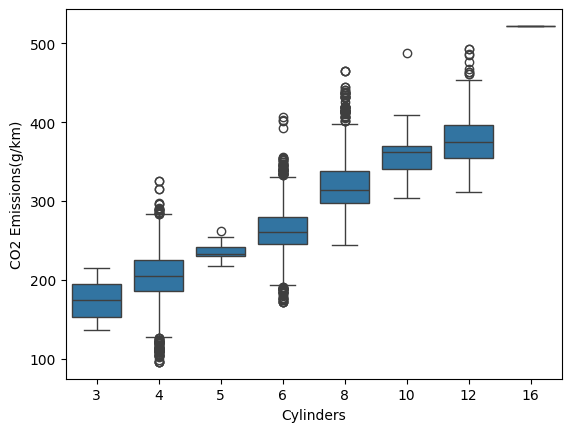

In [219]:
#4
import seaborn as sns

#다른 feature 들은 float 형태이므로 박스가 너무 많이 생깁니다 그래서 정수형인 cylinders 를 선택했습니다
sns.boxplot(data=df,x="Cylinders",y="CO2 Emissions(g/km)")

<Axes: xlabel='Fuel Consumption Comb (mpg)', ylabel='CO2 Emissions(g/km)'>

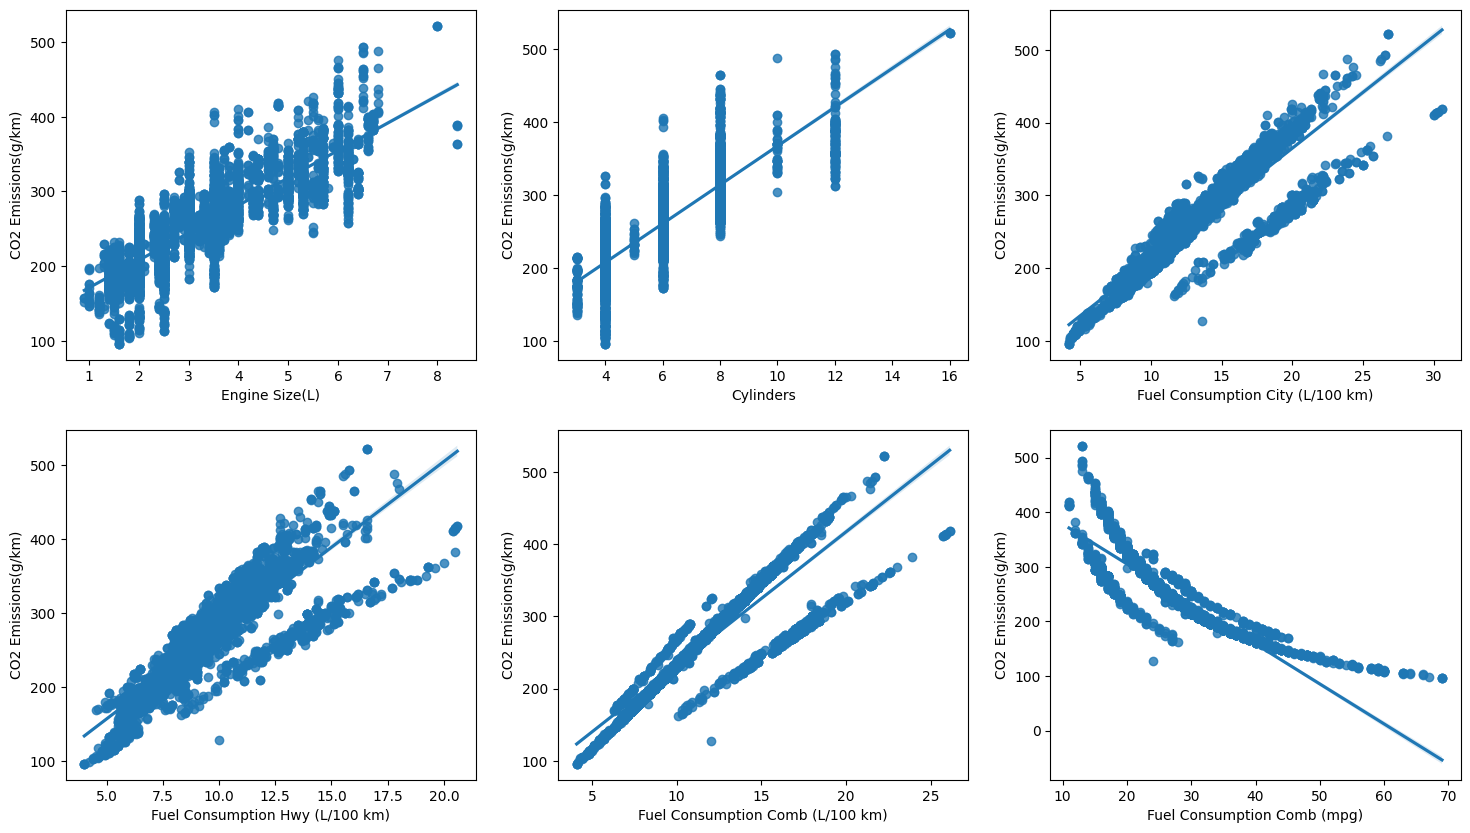

In [220]:
#5
fig, axes = plt.subplots(2,3, figsize=(18, 10))
sns.regplot(data=df, x="Engine Size(L)", y="CO2 Emissions(g/km)", ax=axes[0, 0])
sns.regplot(data=df, x="Cylinders", y="CO2 Emissions(g/km)", ax=axes[0, 1])
sns.regplot(data=df, x="Fuel Consumption City (L/100 km)", y="CO2 Emissions(g/km)", ax=axes[0, 2])
sns.regplot(data=df, x="Fuel Consumption Hwy (L/100 km)", y="CO2 Emissions(g/km)", ax=axes[1, 0])
sns.regplot(data=df, x="Fuel Consumption Comb (L/100 km)", y="CO2 Emissions(g/km)", ax=axes[1, 1])
sns.regplot(data=df, x="Fuel Consumption Comb (mpg)", y="CO2 Emissions(g/km)", ax=axes[1, 2])


In [221]:
#6

X = df3["Fuel Consumption City (L/100 km)"].values.reshape(-1,1)
Y = df3["CO2 Emissions(g/km)"].values.reshape(-1,1)

In [222]:
#7
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
sc_X = StandardScaler()
sc_Y = StandardScaler()
X_std = sc_X.fit_transform(X)
Y_std = sc_Y.fit_transform(Y)

In [223]:
#8
X_train, X_test , Y_train, Y_test = train_test_split(X_std,Y_std,test_size=0.3)
print(f"x_train : {X_train.shape[0]} , x_test : {X_test.shape[0]}")
print(f"y_train : {Y_train.shape[0]} , y_test : {Y_test.shape[0]}")

x_train : 4238 , x_test : 1817
y_train : 4238 , y_test : 1817


In [224]:
#9
import sklearn

sklearn.set_config(display="text")
model = LinearRegression()
model.fit(X_train,Y_train)


LinearRegression()

In [225]:
#10
from sklearn.metrics import r2_score
Y_hat = model.predict(X_test)
rs = r2_score(Y_test,Y_hat)
print(rs)

0.8351063051011716


In [226]:
#11
def my_predict(X_test):
    t = model.coef_
    i = model.intercept_
    Y_hat = X_test*t + i
    return Y_hat
Y_hat1 = my_predict(X_test)
rs1 = r2_score(Y_test,Y_hat1)
print(f"r2 score : {rs}")
print(f"my_predict r2 : {rs1}")




r2 score : 0.8351063051011716
my_predict r2 : 0.8351063051011716


In [227]:
#12
def my_r2_score(Y_test,Y_hat):
    rse = sum((Y_test - Y_hat)**2)/sum((Y_test - Y_test.mean())**2)
    r2 = 1-rse
    return r2[0]

print(f"r2 score : {rs}")
print(f"my r2 score : {my_r2_score(Y_test,Y_hat)}")


r2 score : 0.8351063051011716
my r2 score : 0.8351063051011713


In [228]:
#13
df = pd.read_csv("abalone.csv")
df['Sex'].unique()
# df.info()

<StringArray>
['M', 'F', 'I']
Length: 3, dtype: str

In [234]:
#14

df['Sex'] = df['Sex'].replace({'I': 1, 'F': 2, 'M': 3})
df['Sex'] = df['Sex'].astype(int)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   int64  
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 293.8 KB


In [230]:
#15
X = df[df.columns[1:9]]
Y = df['Sex']
print(X.shape)
print(Y.shape)

(4177, 8)
(4177,)


In [231]:
#16
# X값을 토대로 Y값(성별)이 뭔지 맞추는것이므로 Y는 스케일링하지않고 그대로 둬야 합니다
sc_X = StandardScaler()
X_std = sc_X.fit_transform(X)


In [232]:
#17
X_train, X_test , Y_train, Y_test = train_test_split(X_std,Y,test_size=0.2)
print(f"Xtrain : {X_train.shape} , Xtest : {X_test.shape}")
print(f"Ytrain : {Y_train.shape} , Ytest : {Y_test.shape}")

Xtrain : (3341, 8) , Xtest : (836, 8)
Ytrain : (3341,) , Ytest : (836,)


In [233]:
#18
from sklearn import svm
model = svm.SVC()
model.fit(X_train,Y_train)
Y_hat = model.predict(X_test)

ValueError: Unknown label type: unknown. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [ ]:
#19
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,precision_score,recall_score


acc = accuracy_score(Y_test, Y_hat)
cm = confusion_matrix(Y_test, Y_hat)
precision = precision_score(Y_test, Y_hat, average="macro")
recall = recall_score(Y_test, Y_hat, average=None)
f1 = f1_score(Y_test, Y_hat, average=None)

print(f"accuracy : {acc}")
print(f"confusion : {cm}")
print(f"precision : {precision}")
print(f"recall : {recall}")
print(f"f1 : {f1}")

accuracy : 0.5442583732057417
confusion : [[217   5  47]
 [ 35  60 166]
 [ 67  61 178]]
precision : 0.5372280755471514
recall : [0.80669145 0.22988506 0.58169935]
f1 : [0.73809524 0.31007752 0.5107604 ]


In [ ]:
#20

my_acc_score = np.mean(Y_test == Y_hat)

func_acc_score = accuracy_score(Y_test, Y_hat)

print(f"my accuracy score : {my_acc_score}")
print(f"accuracy score : {func_acc_score}")

my accuracy score : 0.5442583732057417
accuracy score : 0.5442583732057417
